# Models

In [52]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from typing import Literal
from timeit import timeit
from copy import deepcopy

# DataSet

In [53]:
X, y = datasets.make_classification(
    1000, n_informative=10, n_classes=2, random_state=1234
)
df = pd.DataFrame(np.concat([X, y.reshape((-1, 1))], axis=1))
df

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.457387,0.044800,1.065265,-1.938576,1.830386,-1.823374,0.857245,0.595823,-0.152031,-2.044557,...,0.176880,0.081133,1.370691,-0.224305,-3.349422,-1.413306,-2.593940,0.332153,-0.864669,1.0
1,-3.371998,-1.041732,-1.248727,2.209832,3.373579,-0.509559,-1.471555,0.059025,0.676365,0.164998,...,-1.494527,0.818342,0.290898,0.500435,-1.614776,-0.569255,0.883266,-1.485581,-1.523594,1.0
2,0.924621,0.041346,-1.204476,-0.298492,-1.148740,-2.285846,0.827706,-1.945065,-1.076292,0.367645,...,-0.879710,-1.962898,-1.131552,0.493907,4.084628,1.162006,-0.304275,-0.940946,2.311345,1.0
3,-2.192427,1.222494,2.443799,1.200463,-1.753021,-1.619594,-0.487170,0.436088,2.838006,0.348724,...,-0.137425,-0.671823,-0.167581,0.893854,0.603198,0.103318,-0.764099,1.497355,1.807844,0.0
4,-0.137892,-5.301982,0.644057,1.253181,3.023146,-0.949791,-0.531874,-0.519257,-3.174586,0.059826,...,-0.334051,0.660703,-0.141722,0.128261,4.047574,-3.475531,-0.122264,-1.495108,1.215742,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-4.151683,2.587540,1.097802,-1.750928,-1.249860,-0.674999,0.733021,-0.070940,1.532351,-0.698817,...,-1.659382,1.405279,-0.010393,1.912993,0.528691,0.488432,-1.657764,-0.536556,1.416409,0.0
996,-0.163481,1.740797,0.540521,1.928581,-0.376303,-0.059143,-1.744455,-0.417569,-0.044855,-0.565618,...,-0.200986,-2.026890,-0.201312,0.395147,-1.462199,-1.295306,-5.214360,-1.455780,2.483952,0.0
997,-1.329040,0.913590,1.379892,-3.484480,-2.322578,1.082249,0.520983,-1.813182,2.184034,1.331990,...,-0.572115,1.630071,-0.708778,-0.665452,3.579007,0.826238,-0.430236,-0.004180,2.885431,1.0
998,3.568538,-1.032928,2.391924,1.555306,-1.836071,-1.000057,1.678337,-0.466937,-7.435656,0.170554,...,-0.558524,0.581085,-0.596668,-0.364888,9.201106,2.653935,-1.355794,-3.543245,0.009952,0.0


# Prepare Training and testing data

In [54]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=.25,
    random_state=1234
)

# Train the Sklearn Neuron Network

In [55]:
sk_network = MLPClassifier((50, 50), random_state=1234, max_iter=500)
sk_training_time = timeit("sk_network.fit(x_train, y_train)", number=1,
       globals={
           "sk_network": sk_network,
           'x_train': x_train,
           'y_train': y_train
       })
print(f'time needed for Sklearn Network to train: {sk_training_time:.2f}s')
print(f"Number of training iterations:", sk_network.n_iter_)

time needed for Sklearn Network to train: 0.90s
Number of training iterations: 189


# Test the Sklearn Neuron Network 

In [56]:
sk_score = sk_network.score(x_test, y_test)
print(f"from Scratch network accuracy: {sk_score:%}")

from Scratch network accuracy: 92.000000%


# Build the Neurons Network

In [62]:
class ClassificationNeuronsNetwork:

    @staticmethod
    def _round_y(y):
        return np.where(y > .5, 1, 0)

    @staticmethod
    def _sigmoid(z: np.ndarray):
        z_ = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z_))
    
    @staticmethod
    def _sigmoid_derivative(a):
        return a * (1 - a)


    def _ReLu(self, z):
        return np.where(z > 0, z, self.alpha*z)


    def _ReLu_derivative(self, a):
        return np.where(a > 0, 1, self.alpha)

    @staticmethod
    def _tanh(z): return np.tanh(z)

    @staticmethod
    def _tanh_derivative(a): return 1 / np.tanh(a)

    def __init__(self, hidden_layer_sizes: tuple[int,...], activation: Literal['logistic', 'relu', 'tanh'] = 'logistic', 
                 learning_rate_init=0.005, tol: float = 1e-6, max_iter=200, random_stat: int|None = None
                 , early_stopping: bool = False, n_iter_no_change: int = 10) -> None:
        self._ACTIVATION_FUNC_MAPPING = {
                'logistic': self._sigmoid,
                'relu': self._ReLu,
                'tanh': self._tanh
            }
        
        self._ACTIVATION_FUNC_SLOPE_MAPPING = {
                'logistic': self._sigmoid_derivative,
                'relu': self._ReLu_derivative,
                'tanh': self._tanh_derivative
            }
        
        self.hidden_layer_sizes = hidden_layer_sizes
        self.layer_sizes = self.hidden_layer_sizes + (1,)
        self._n_hidden_layers = len(self.hidden_layer_sizes)
        self.n_layers = self._n_hidden_layers + 1

        self.lr = self.learning_rate_init= learning_rate_init

        self.max_iter = max_iter
        self.n_iter_ = 0

        self.weights: list[np.ndarray]
        self.biases: list[np.ndarray]

        self.RNG = np.random.RandomState(random_stat)

        self.alpha = 0.001

        self.labels: np.ndarray = np.array([])
        self.n_labels = 0

        if activation_func:=self._ACTIVATION_FUNC_MAPPING.get(activation):
            self._activation_func = activation_func
            self._activation_func_slope = self._ACTIVATION_FUNC_SLOPE_MAPPING[activation]
        else: 
            raise ValueError(f'You should choose only one of these options for an activation: {tuple(self._ACTIVATION_FUNC_MAPPING)} not {activation}')

        self.tol = tol
        self.early_stopping = early_stopping
        self.n_iter_no_change = n_iter_no_change

    def _predict_by_layer(self, X:np.ndarray, layer: int):
        return (X @ self.weights[layer]) + self.biases[layer]

    def predict_prob(self, X: np.ndarray):
        a = X
        for layer in range(self._n_hidden_layers):
            z = self._predict_by_layer(a, layer)
            a = self._activation_func(z)
        return self._output_layer_activation_func(
            self._predict_by_layer(
                a, self._n_hidden_layers
            )
        )

    def predict(self, X: np.ndarray):
        y_predict = self.predict_prob(X)
        return (self.labels[np.argmax(y_predict, axis=-1)] if self.n_labels > 2 else self._round_y(y_predict)).flatten()
    
    def _activation_func(self, z: np.ndarray) -> np.ndarray: ...

    
    def _activation_func_slope(self, a: np.ndarray) -> np.ndarray: ...

    
    def _output_layer_activation_func(self, z) -> np.ndarray: ...

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=-1, keepdims=True))
        return  exp_z/ np.sum(exp_z, axis=-1, keepdims=True)

    def _make_weights_biases(self, n_features):
        weight_shapes = (
            [(n_features, self.layer_sizes[0])]
            +
            [(self.layer_sizes[layer-1], self.layer_sizes[layer]) for layer in range(1, self.n_layers)]
        )
        bias_shapes = [
            (1, self.layer_sizes[layer]) 
            for layer in range(self.n_layers)]

        self.weights = [self.RNG.standard_normal(weight_shapes[layer]) * np.sqrt(1.0 / weight_shapes[layer][0]) for layer in range(self.n_layers)]
        
        self.biases =  [np.zeros(bias_shapes[layer]) for layer in range(self.n_layers)]

    def _prepare_labels(self, y: np.ndarray):
        if len(y.shape) > 1 and y.shape[1] > 1: # To see if y is one-hot encoded or not
            return y
        # If y is not one-hot encoded
        # we will encode the labels
        y_ = y.flatten()
        if self.n_labels == 2:
            return (y_ == self.labels[-1]).astype(float).reshape((-1, 1))
        one_hot_encoder = np.eye(len(self.labels))
        y_encoded = np.empty((len(y_), len(self.labels)))
        for i, label in enumerate(self.labels):
            y_encoded[y_ == label] = one_hot_encoder[i]
        return y_encoded

    def _load_labels(self, y):
        self.labels = np.unique(y)
        self.labels.sort()
        self.n_labels = len(self.labels)
        if self.n_labels > 2: 
            self._output_layer_activation_func = self._softmax
            self.layer_sizes = self.layer_sizes[:-1] + (self.n_labels,)
        else: 
            self._output_layer_activation_func = self._sigmoid
            self.layer_sizes = self.layer_sizes[:-1] + (1,)

    def _change_in_wights_biases(self, old_error, curr_error):
        mean_per_layer = lambda layer_weights: np.mean(layer_weights)
        return abs(
                    np.mean(list(map(mean_per_layer, curr_error))) 
                    - 
                    np.mean(list(map(mean_per_layer, old_error)))
                )

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        self._load_labels(y)

        y_ = self._prepare_labels(y)

        self._make_weights_biases(n_features)

        self.alpha = 0.001

        self.n_iter_ = 0

        old_error_terms: list[np.ndarray] = [np.zeros((1,))]
        n_iter_no_change = 0

        for epoch in range(self.max_iter):
            z_predictions = []
            activation_outputs = [X]
            
            a = X
            
            for layer in range(self._n_hidden_layers):
                z = self._predict_by_layer(a, layer)
                a = self._activation_func(z)
                z_predictions.append(z)
                activation_outputs.append(a)

            z = self._predict_by_layer(a, self._n_hidden_layers)
            a = self._output_layer_activation_func(z)
            z_predictions.append(z)
            activation_outputs.append(a)

            y_predict = activation_outputs[-1]

            error_terms = [(y_predict - y_)]

            for layer in reversed(range(self._n_hidden_layers)):
                error_terms.append(
                    (error_terms[-1] @ self.weights[layer+1].T) 
                    * 
                    self._activation_func_slope(activation_outputs[layer + 1])
                )

            error_terms.reverse()

            for layer in range(self.n_layers):
                current_dz = error_terms[layer] / n_samples

                dw = activation_outputs[layer].T @ current_dz
                db = np.sum(current_dz, axis=0, keepdims=True)

                self.weights[layer] -= self.lr * dw
                self.biases[layer] -= self.lr * db

            if self.early_stopping:
                if self._change_in_wights_biases(old_error_terms, error_terms) < self.tol:
                    if n_iter_no_change == self.n_iter_no_change:
                        return
                    n_iter_no_change += 1
                else: 
                    n_iter_no_change = 0
                old_error_terms = error_terms
                

            self.n_iter_ += 1
    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))

# Build the network and train it

In [ ]:
my_network = ClassificationNeuronsNetwork(
    hidden_layer_sizes=(50, 50,), 
    activation='relu', 
    max_iter=200, 
    learning_rate_init=0.05, 
    random_stat=1234,
    early_stopping=True,
    tol=5e-6
)

my_training_time = timeit('my_network.fit(x_train, y_train)',
                          number=1,
                          globals={
                              'my_network': my_network,
                              'x_train': x_train,
                              'y_train': y_train
                          })
print(f'time needed for my Network to train: {my_training_time:.2f}s')
print(f"Number of training iterations:", my_network.n_iter_)

time needed for my Network to train: 0.68s
Number of training iterations: 200


# Test my network

In [69]:
my_score = my_network.score(x_test, y_test)
print(f"from Scratch network accuracy: {my_score:%}")

from Scratch network accuracy: 92.400000%


# The Confusion Matrix for both the from Scratch network and the Sklearn's network

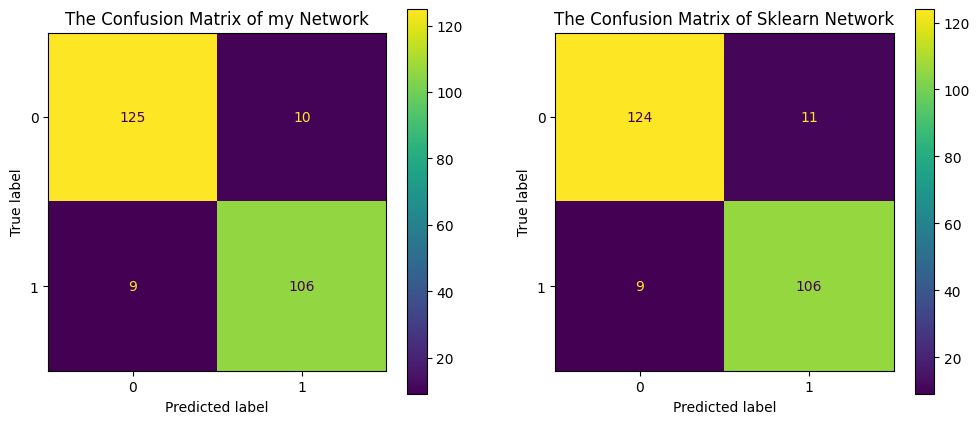

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axe = plt.subplots(1, 2, figsize=(12, 5))
axe[0].set_title('The Confusion Matrix of my Network')
axe[1].set_title('The Confusion Matrix of Sklearn Network')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, my_network.predict(x_test))
).plot(ax=axe[0],)
ConfusionMatrixDisplay(
    confusion_matrix(y_test, sk_network.predict(x_test))
).plot(ax=axe[1])

# Comparison between out from Scratch network and Sklearn's network

In [71]:
index = [
    "Sklearn", 'Scratch'
]

columns = [
    'Number of training iterations',
    'initial learning rate(α)',
    'Accurce',
    'Training time'
]

data = [
    [sk_network.n_iter_, sk_network.learning_rate_init, sk_score, sk_training_time], # type: ignore
    [my_network.n_iter_, my_network.learning_rate_init, my_score, my_training_time]
]

comparing_table = pd.DataFrame(
    data=data,
    columns=columns,
    index=index
)

comparing_table['Training time'] = comparing_table['Training time'].round(3).astype(str) + 's'
comparing_table['Accurce'] = (comparing_table['Accurce']*100).round(2).astype(str) + '%'

comparing_table 

,Number of training iterations,initial learning rate(α),Accurce,Training time
Sklearn,189,0.001,92.0%,0.899s
Scratch,200,0.050,92.4%,0.685s
